In [ ]:
# ── Install required libraries ──────────────────────────────────────
!pip install -q transformers datasets evaluate torch pandas matplotlib seaborn scikit-learn kagglehub librosa fvcore

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────
import torch
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa

from transformers import (
    AutoFeatureExtractor, # was AutoTokenizer
    AutoModelForAudioClassification, # was AutoModelForSequenceClassification
    Wav2Vec2Processor,
    TrainingArguments,
    Trainer,
)
import evaluate

# Used for preprocessing the audio datasets
from torch.utils.data import DataLoader, random_split
from sklearn.preprocessing import LabelEncoder

# Print PyTorch and device information
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")


PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : NVIDIA L4


In [ ]:
# ── Load HuBERT model ───────────────────────────────────────────────

# Use Facebook's HuBERT base model
MODEL_CHECKPOINT = "facebook/hubert-base-ls960"

# Use AutoFeatureExtractor instead of AutoTokenizer (for compatibility with audio, not text)
feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_CHECKPOINT)
print(f"Feature extractor loaded: {MODEL_CHECKPOINT}")

Feature extractor loaded: facebook/hubert-base-ls960


In [ ]:
# Get access to my Google Drive (for loading the datasets)
from google.colab import drive
drive.mount('/content/drive')

import os
# Check what is actually inside that folder
print(os.listdir('/content/drive/MyDrive/HuBERT/BirdCLEF/'))

Mounted at /content/drive
['spotted_towhee', 'house_wren', 'northern_cardinal', 'common_raven', 'european_starling', 'curve_billed_thrasher', 'song_sparrow', 'red_winged_blackbird', 'red_crossbill', 'barn_swallow']


In [ ]:
# Rebuild the label dictionaries globally
species = sorted([d for d in os.listdir('/content/drive/MyDrive/HuBERT/BirdCLEF/') if os.path.isdir(os.path.join('/content/drive/MyDrive/HuBERT/BirdCLEF/', d))])
labels = species
label2id = {name: i for i, name in enumerate(species)}
id2label = {i: name for i, name in enumerate(species)}
print(f"Unique labels: {labels}")

Unique labels: ['barn_swallow', 'common_raven', 'curve_billed_thrasher', 'european_starling', 'house_wren', 'northern_cardinal', 'red_crossbill', 'red_winged_blackbird', 'song_sparrow', 'spotted_towhee']


In [ ]:
!cp -r /content/drive/MyDrive/HuBERT/BirdCLEF/ /content/BirdCLEF_local/
# Verify the copy worked
if os.path.exists(target_dir):
    contents = os.listdir(target_dir)
    print(f"Local directory created. Found {len(contents)} items.")
    print(f"Samples: {contents[:5]}")
else:
    print("Error: Target directory was not created.")

In [ ]:
import os
import librosa
import numpy as np
from datasets import Dataset, DatasetDict, concatenate_datasets, Features, Value, ClassLabel

def audio_generator(data_path, limit_per_class=500):
    # Get sorted folder names (bird species)
    species = sorted([d for d in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, d))])
    label2id = {name: i for i, name in enumerate(species)}

    for bird in species:
        print(f"Extracting official features for: {bird}")
        folder_path = os.path.join(data_path, bird)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.ogg', '.wav', '.mp3'))]

        count = 0
        for f in files:
            if count >= limit_per_class: break

            file_path = os.path.join(folder_path, f)
            try:
                # 1. Load the audio
                audio, _ = librosa.load(file_path, sr=16000)

                # 2. OFFICIAL HUGGING FACE PREPROCESSING
                encoded = feature_extractor(
                    audio,
                    sampling_rate=16000,
                    max_length=160000,
                    truncation=True,
                    padding="max_length",
                    return_tensors="np"
                )

                # 3. Yield to the dataset builder
                yield {
                    "input_values": encoded["input_values"][0],
                    "label": label2id[bird]
                }
                count += 1
            except Exception as e:
                print(f"Skipping {f} due to error: {e}")

# ── RUN THE GENERATOR ──────────────────────────────────────────────────
print("Building dataset file-by-file (This will prevent RAM crashes)...")
hf_dataset = Dataset.from_generator(
    audio_generator,
    gen_kwargs={"data_path": '/content/BirdCLEF_local/'}
)

Building dataset file-by-file (This will prevent RAM crashes)...


In [ ]:
import os
import librosa
import numpy as np
from datasets import Dataset, DatasetDict, concatenate_datasets, Features, Value, ClassLabel

# ── CAST TO CLASSLABEL FOR STRATIFICATION ─────────────────────────
# This tells the dataset that 'label' is a categorical ClassLabel (0-9)
species_names = sorted([d for d in os.listdir('/content/BirdCLEF_local/') if os.path.isdir(os.path.join('/content/BirdCLEF_local/', d))])

# Create the feature schema
class_features = hf_dataset.features.copy()
class_features["label"] = ClassLabel(names=species_names)

# Cast the dataset to the new schema
hf_dataset = hf_dataset.cast(class_features)

# ── SPLIT THE DATASET (70/20/10) ──────────────────────────────────────
print("Splitting BirdCLEF dataset into stratified Train / Validate / Test sets")
first_split = hf_dataset.train_test_split(test_size=0.1, seed=42, stratify_by_column="label") # take 10% for Test
second_split = first_split['train'].train_test_split(test_size=0.222, seed=42, stratify_by_column="label") # 22.2% of 90% left = 20% for Validate

# Build Large dataset (5000 Total, 500 per class)
final_large_datasets = DatasetDict({
    'train': second_split['train'], # 70%
    'validation': second_split['test'], # 20%
    'test': first_split['test'] # 10%
})

def _create_stratified_subset(dataset_dict, train_per_class=105, validate_per_class=30, test_per_class=15, seed=42):
    rng = np.random.default_rng(seed)
    small_dataset = {}
    splits_mapping = {'train': train_per_class, 'validation': validate_per_class, 'test': test_per_class}

    for split_name, per_class in splits_mapping.items():
        print(f"Processing {split_name} subset (Randomized)... ")
        ds = dataset_dict[split_name] # e.g. {[0,3,2,0,1,6,8,4,9...]} (labels for a dataset)
        # Optimization: Use np.where to find indices instead of .filter() which is slow
        labels_array = np.array(ds['label']) # flattens to array
        # Collect #_per_class amount from dataset split
        subsets = []

        for class_id in range(10):
            # Find all indices where label matches class_id
            idx = np.where(labels_array == class_id)[0] # e.g. [0,3,6]
            # Shuffle indices before selecting so training/test sets are diverse
            rng.shuffle(idx)
            selected_idx = idx[:min(per_class, len(idx))] # select up to amount we need or available
            subsets.append(ds.select(selected_idx)) # Add to collection

        small_dataset[split_name] = concatenate_datasets(subsets).shuffle(seed=seed)
    return DatasetDict(small_dataset)

print("Creating the small subset w/ Randomized indexing...")
final_small_datasets = _create_stratified_subset(final_large_datasets)

# Save both datasets
LARGE_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/hubert_bird_datasets_large_official'
SMALL_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/hubert_bird_datasets_small_official'

final_large_datasets.save_to_disk(LARGE_SAVE_PATH)
final_small_datasets.save_to_disk(SMALL_SAVE_PATH)

print(f"Success! Large AST dataset saved to: {LARGE_SAVE_PATH}")
print(f"Success! Small AST dataset saved to: {SMALL_SAVE_PATH}")

Splitting BirdCLEF dataset into stratified Train / Validate / Test sets
Creating the small subset (Optimized)...
Processing train subset...
Processing validation subset...
Processing test subset...


Saving the dataset (0/5 shards):   0%|          | 0/3501 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/999 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/1050 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/150 [00:00<?, ? examples/s]

Success! Large AST dataset saved to: /content/drive/MyDrive/HuBERT_Thai/hubert_bird_datasets_large_official
Success! Small AST dataset saved to: /content/drive/MyDrive/HuBERT_Thai/hubert_bird_datasets_small_official


In [ ]:
LARGE_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/hubert_bird_datasets_large_official'
SMALL_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/hubert_bird_datasets_small_official'
DATASET_PATH = SMALL_SAVE_PATH # <----------- change if need
print(os.listdir(DATASET_PATH))

['dataset_dict.json', 'train', 'validation', 'test']


In [ ]:
from datasets import load_from_disk

# ── Load datasets from preprocessed files ─────────────────────────────────────────────────
def load_datasets(path):
    print(f'Loading HF Datasets from {path}...')
    loaded_datasets = load_from_disk(path)

    train_dataset = loaded_datasets['train']
    val_dataset = loaded_datasets['validation']
    test_dataset = loaded_datasets['test']

    print("Datasets have been loaded.")
    return train_dataset, val_dataset, test_dataset

# ── Metric functions for measuring accuracy ─────────────────────────────────────────────────

# Load evaluate metrics
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    # Accuracy metric
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    prec = precision_metric.compute(predictions=predictions, references=labels, average="macro")
    rec = recall_metric.compute(predictions=predictions, references=labels, average="macro")
    # Return a dict with both scores
    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": prec["precision"],
        "recall": rec["recall"]
    }


In [ ]:
# ── Load Datasets ─────────────────────────────────────────────────
train_dataset, val_dataset, test_dataset = load_datasets(DATASET_PATH)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Loading HF Datasets from /content/drive/MyDrive/HuBERT_Thai/hubert_bird_datasets_small_official...
Datasets have been loaded.
Train: 1050
Val:   300
Test:  150


In [ ]:
# ── Evaluate Base HuBERT (Untrained) ─────────────────────────────────────────────────

print("=" * 50)
print("Evaluating Base HuBERT (Untrained Classification Head)")
print("=" * 50)

# 1. Load a fresh, untrained model
base_model = AutoModelForAudioClassification.from_pretrained(
    "facebook/hubert-base-ls960",
    num_labels=10
)

# 2. Create a temporary trainer just for evaluation
base_trainer = Trainer(
    model=base_model,
    args=TrainingArguments(output_dir="/tmp/base_eval", per_device_eval_batch_size=16, report_to="none"),
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# 3. Predict and print
base_results = base_trainer.predict(test_dataset)
print(f"  Base Accuracy   : {base_results.metrics['test_accuracy']:.4f}")
print(f"  Base F1 Score   : {base_results.metrics['test_f1']:.4f}")



Evaluating Base HuBERT (Untrained Classification Head)


config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
projector.weight  | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Base Accuracy   : 0.1067
  Base F1 Score   : 0.0371


In [ ]:
# --- FREE UP GPU MEMORY ---
import gc

# Delete the base model and trainer from memory so the GPU has room to train
del base_model
del base_trainer
gc.collect()
torch.cuda.empty_cache()
print("Cleared GPU memory for fine-tuning!")

Cleared GPU memory for fine-tuning!


In [ ]:
# ── Setup to Fine-tune HuBERT ─────────────────────────────────────────────────

model = AutoModelForAudioClassification.from_pretrained(
    MODEL_CHECKPOINT, # Load the pretrained checkpoint (HuBERT-base)
    num_labels=10, # 10 bird species
)

train_epochs=10 # Train for 10 epochs
lr=2e-5 # very small learning rate (0.00002)
train_batch_size=8
eval_batch_size=16

training_args = TrainingArguments(
    output_dir="/content/training_checkpoints",
    num_train_epochs=train_epochs,
    learning_rate=lr,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    seed=42, # random seed 42
    eval_strategy="epoch", # Evaluate and save after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True, # After training, reload the best performing version of the model for evaluation
    metric_for_best_model="accuracy", # Metric used to decide which checkpoint is the best (uses accuracy function from part 4)
    save_total_limit=1,
    report_to="none",
)

trainer_birdclef = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
projector.weight  | MISSING | 
projector.bias    | MISSING | 
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# ── Train HuBERT ─────────────────────────────────────────────────
trainer_birdclef.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,2.088709,0.360000,0.293854,0.288150,0.360000
2,No log,1.697227,0.476667,0.408570,0.429700,0.476667
3,No log,1.591256,0.516667,0.516539,0.649177,0.516667
4,1.898311,1.374432,0.590000,0.573246,0.619033,0.590000
5,1.898311,1.287015,0.616667,0.606425,0.648651,0.616667
6,1.898311,1.182189,0.646667,0.641014,0.668861,0.646667
7,1.898311,1.104071,0.696667,0.690742,0.717802,0.696667
8,1.277785,1.075971,0.690000,0.677395,0.712575,0.690000
9,1.277785,1.084511,0.663333,0.663053,0.685599,0.663333
10,1.277785,1.055758,0.673333,0.669339,0.681148,0.673333


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1320, training_loss=1.4519293120413115, metrics={'train_runtime': 1821.4288, 'train_samples_per_second': 5.765, 'train_steps_per_second': 0.725, 'total_flos': 9.5327715168e+17, 'train_loss': 1.4519293120413115, 'epoch': 10.0})

In [ ]:
LARGE_MODEL_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/hubert_bird_model_large_5000'
SMALL_MODEL_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/hubert_bird_model_small_1500'
SAVE_PATH = SMALL_MODEL_SAVE_PATH

In [ ]:
# After training finishes:
print("Saving the BEST model permanently to Google Drive...")
# This only saves the final weights (~300MB), not the 10 epochs of junk
trainer_birdclef.save_model(SAVE_PATH)
print("Done!")

Saving the BEST model permanently to Google Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done!


In [ ]:
trainer_birdclef.compute_metrics = compute_metrics

# ── Report final validation accuracy and F1 ───────────────────────

# Parameter Count (Model Size)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params / 1e6:.2f} Million")

# Training Speed (Samples per second)
# We pull this from the trainer state after training is done
if len(trainer_birdclef.state.log_history) > 0:
    train_metrics = trainer_birdclef.state.log_history[-1]
    # Sometimes the last entry is just an eval log, so we check for the key
    if 'train_samples_per_second' in train_metrics:
        print(f"Training throughput: {train_metrics['train_samples_per_second']:.2f} samples/sec")

print("-" * 50)

# Inference Latency + Final Accuracy (Calculated together)
import time
start_inference = time.time()

# predict() does exactly what evaluate() does, but gives us the raw predictions too
results = trainer_birdclef.predict(test_dataset)

end_inference = time.time()

# Calculate Latency logic
total_time = end_inference - start_inference
latency_per_sample = (total_time / len(test_dataset)) * 1000

# Print Everything
print("=" * 50)
print("BirdCLEF Fine-Tuned — Final Test Results (Test Set)")
print("=" * 50)
# Note: Results from predict() are stored in results.metrics
print(f"  Accuracy   : {results.metrics['test_accuracy']:.4f}")
print(f"  F1 Score   : {results.metrics['test_f1']:.4f}")
print(f"  Precision  : {results.metrics['test_precision']:.4f}")
print(f"  Recall     : {results.metrics['test_recall']:.4f}")
print("-" * 50)
print(f"Total Test Inference Time: {total_time:.2f} seconds")
print(f"Average Latency: {latency_per_sample:.2f} ms per bird call")

Total Parameters: 94.57 Million
Training throughput: 5.76 samples/sec
--------------------------------------------------


BirdCLEF Fine-Tuned — Final Test Results (Test Set)
  Accuracy   : 0.6467
  F1 Score   : 0.6204
  Precision  : 0.6340
  Recall     : 0.6467
--------------------------------------------------
Total Test Inference Time: 15.68 seconds
Average Latency: 104.50 ms per bird call


In [ ]:
# ── MACs & FLOPs ───────────────────────────────

from fvcore.nn import FlopCountAnalysis
import torch

# 1. Create a dummy input that matches HuBERT's expected wave shape (1 batch, 160,000 samples)
dummy_wave = torch.randn(1, 160000).to(model.device)

# 2. Run the Flop analyzer
print("Calculating HuBERT MACs...")
flops_hubert = FlopCountAnalysis(model, dummy_wave)

# 3. Suppress the massive layer-by-layer printout and just get the total
flops_hubert.unsupported_ops_warnings(False)

macs_total = flops_hubert.total()
flops_total = macs_total * 2

print("\n" + "="*40)
print(f"HuBERT Computational Complexity")
print("="*40)
print(f"Total MACs (GigaMACs): {macs_total / 1e9:.2f} GMACs")
print(f"Total FLOPs (GigaFLOPs): {flops_total / 1e9:.2f} GFLOPs")
print(f"Total Parameters:      {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

Calculating HuBERT MACs...

HuBERT Computational Complexity
Total MACs (GigaMACs): 69.71 GMACs
Total FLOPs (GigaFLOPs): 139.41 GFLOPs
Total Parameters:      94.57 M


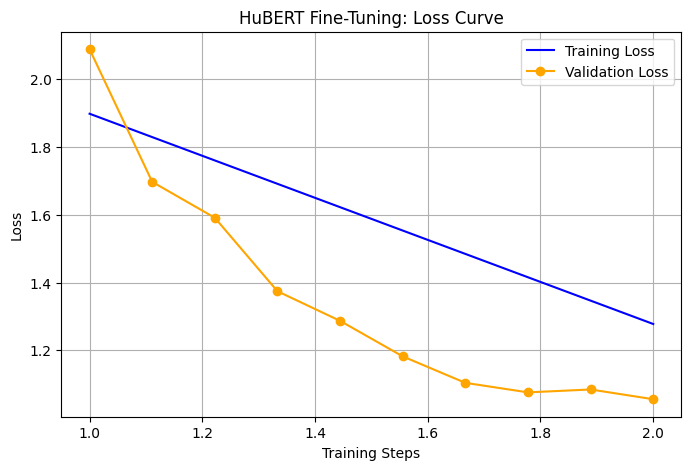

In [ ]:
# ── PLOT LOSS CURVES ────────────────────────────────────────────────────────
# extract the internal logs from trainer object
history = trainer_birdclef.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

epochs_train = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_train, train_loss, label='Training Loss', color='blue')
plt.plot(np.linspace(1, len(train_loss), len(val_loss)), val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('HuBERT Fine-Tuning: Loss Curve')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

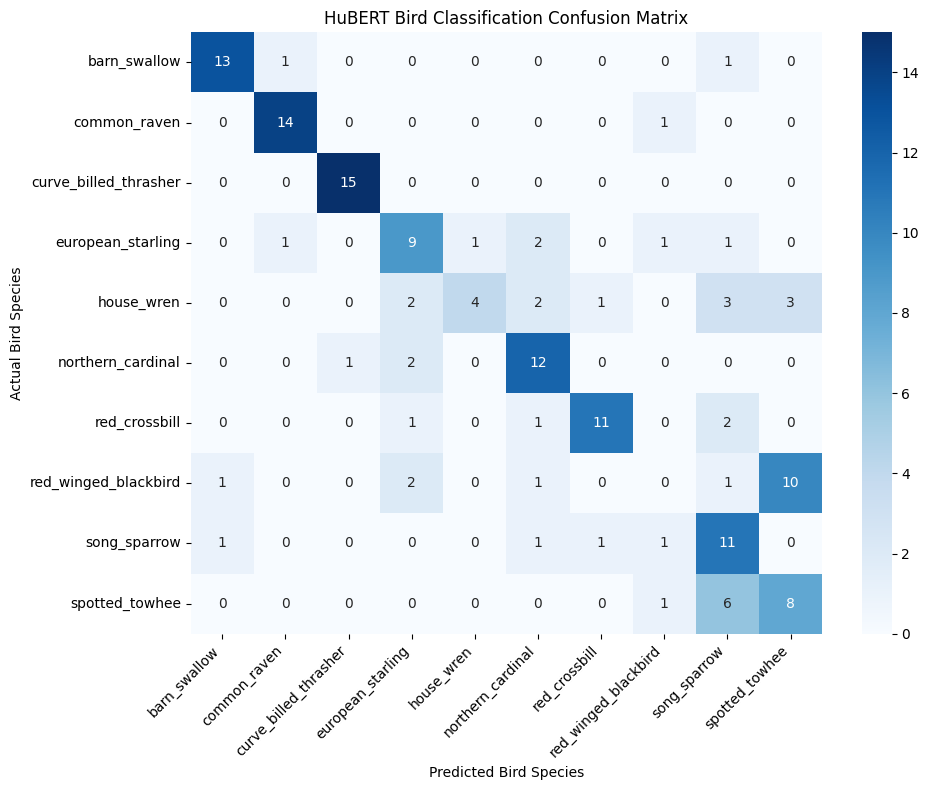

In [ ]:
# ── PLOT CONFUSION MATRIX ───────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

# Get model's raw predictions on test dataset
predictions_output = trainer_birdclef.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# label the axes
unique_labels = sorted(list(set(labels)))

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Seaborn plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('HuBERT Bird Classification Confusion Matrix')
plt.xlabel('Predicted Bird Species')
plt.ylabel('Actual Bird Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── SHOW CLASS-LEVEL REPORT ───────────────────────────────────────────────────

from sklearn.metrics import classification_report

# 1. Get predictions
print("Generating class-level report...")
predictions_output = trainer_birdclef.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# 2. Get the bird names in the correct order
# id2label should look like {0: "Barn swallow", 1: "Common raven", ...}
target_names = [id2label[i] for i in range(10)]

# 3. Print the holy grail of research tables
report = classification_report(y_true, y_pred, target_names=target_names)
print("\n" + "="*60)
print("CLASS-LEVEL PERFORMANCE REPORT")
print("="*60)
print(report)

Generating class-level report...



CLASS-LEVEL PERFORMANCE REPORT
                       precision    recall  f1-score   support

         barn_swallow       0.87      0.87      0.87        15
         common_raven       0.88      0.93      0.90        15
curve_billed_thrasher       0.94      1.00      0.97        15
    european_starling       0.56      0.60      0.58        15
           house_wren       0.80      0.27      0.40        15
    northern_cardinal       0.63      0.80      0.71        15
        red_crossbill       0.85      0.73      0.79        15
 red_winged_blackbird       0.00      0.00      0.00        15
         song_sparrow       0.44      0.73      0.55        15
       spotted_towhee       0.38      0.53      0.44        15

             accuracy                           0.65       150
            macro avg       0.63      0.65      0.62       150
         weighted avg       0.63      0.65      0.62       150



### 🔍 Label Swap Debugger: Red-winged Blackbird
Since the model is confusing every single Red-winged Blackbird for a Spotted Towhee, let's listen to the actual data inside the `red_winged_blackbird` class to see if the labels are correct.

In [ ]:
import numpy as np
from IPython.display import Audio, display

# Find the ID for Red-winged Blackbird
target_id = label2id.get('red_winged_blackbird')
towhee_id = label2id.get('spotted_towhee')

print(f"Target Class: red_winged_blackbird (ID: {target_id})")
print(f"Confused Class: spotted_towhee (ID: {towhee_id})")
print("\nPlaying 3 samples labeled as 'red_winged_blackbird' from the test set...")

# Filter test dataset for this specific label
samples = [ex for ex in test_dataset if ex['label'] == target_id]

for i, example in enumerate(samples[:3]):
    print(f"Sample {i+1}:")
    audio_data = np.array(example['input_values']).flatten()
    display(Audio(audio_data, rate=16000))

print("\nIf these sounds are high-pitched 'Conk-la-ree!' songs, the label is correct and the model is failing. If they sound like a mechanical 'chrrr' or trill, they might actually be Spotted Towhees.")

Target Class: red_winged_blackbird (ID: 7)
Confused Class: spotted_towhee (ID: 9)

Playing 3 samples labeled as 'red_winged_blackbird' from the test set...
Sample 1:


Sample 2:


Sample 3:



If these sounds are high-pitched 'Conk-la-ree!' songs, the label is correct and the model is failing. If they sound like a mechanical 'chrrr' or trill, they might actually be Spotted Towhees.


In [ ]:
# This function now dynamically looks up the name based on your actual folders
def decode_label(label_str):
    # Hugging Face pipeline returns strings like 'LABEL_0', 'LABEL_1', etc.
    label_id = int(label_str.replace('LABEL_', ''))
    # We use the global id2label mapping
    return id2label[label_id]

# Mapping to bird facts (keys must match folder names, although we already standardize during the demo)
bird_facts = {
    "barn_swallow": "They are the most widespread swallow in the world, but in America, they love building mud nests right on human porches.",
    "common_raven": "Ravens are crazy smart—they actually use logic to solve puzzles and have been known to sled down snowy roofs just for fun.",
    "curve_billed_thrasher": "The jazz musicians of the desert; they don't just sing, they 'thash' their bills through debris to find insects while singing.",
    "european_starling": "Total acoustics experts! They can mimic human speech, car alarms, and even the songs of other birds in your dataset.",
    "house_wren": "Don't let the size fool you; these tiny guys are fiercely territorial and will aggressively dive-bomb much larger animals.",
    "northern_cardinal": "Unlike most songbirds, both males and females sing.",
    "red_crossbill": "Their beaks are literally crossed! This specialized 'tool' lets them pry open pine cones.",
    "red_winged_blackbird": "The 'bouncers' of the marsh. Their 'Conk-la-ree!' song is very loud.",
    "song_sparrow": "Every male Song Sparrow has a unique, customized song—like a musical fingerprint.",
    "spotted_towhee": "They are the kings of the 'double-scratch'—a hop-and-kick move they use to find food."
}

In [ ]:
# ── Setup Demo ────────────────────────────

from transformers import pipeline
from IPython.display import display, Image, Audio
import time
import os
import librosa
import numpy as np

# Re-initialize the pipeline
classification_tool = pipeline(
    "audio-classification",
    model=model,
    feature_extractor=feature_extractor,
    device=0 if torch.cuda.is_available() else -1
)

# Demo / Inference
def bert_demo(file_path):
    # Load and process using the SAME logic as training (10 seconds, 16k sr)
    audio, _ = librosa.load(file_path, sr=16000)

    # Use the classification tool directly on the array or path
    probabilities = classification_tool(audio)

    # probabilities look like -> (e.g., {'label': 'LABEL_1', 'score': 0.98})
    result = probabilities[0]
    raw_label = result['label'] # e.g. 'LABEL_0'
    confidence = result['score'] * 100

    raw_bird_name = decode_label(raw_label) # e.g., "barn_swallow" (Directly from folder name)
    search_name = raw_bird_name.lower().replace(" ", "_") # e.g., "barn_swallow" (Used for Image/Facts keys)
    bird_name = search_name.replace("_", " ").title() # e.g., "Barn Swallow" (Used for Chat display)

    fact = bird_facts.get(search_name, "Truly one of America's finest birbs.")

    # --- Output ---
    print(f"[Bird 1]: Yo bert\n")
    time.sleep(1.5)
    print(f"[Bert]: Yo\n")
    time.sleep(1.5)
    print(f"[Bird 1]: What kinda bird iz dith?\n")
    time.sleep(1.5)
    print(f"[Bert]: I'm {confidence:.1f}% sure that's a {bird_name}:")
    time.sleep(1.5)
    print("-" * 40)

    # Display Image
    IMAGE_PATH = f'/content/drive/MyDrive/HuBERT/bird_photos/{search_name}.jpg'
    if os.path.exists(IMAGE_PATH):
        display(Image(filename=IMAGE_PATH, width=400))

    # Play example from test set
    for i in range(len(test_dataset)):
        # test_dataset[i]['label'] is an INT (e.g., 0). We map it back to "barn_swallow"
        dataset_bird_name = id2label[test_dataset[i]['label']].lower().replace(" ", "_")
        if dataset_bird_name == search_name:
            audio_array = np.array(test_dataset[i]['input_values']).flatten()
            display(Audio(audio_array, rate=16000))
            break

    print(f"[Bert]: {fact}\n\n")
    time.sleep(2.5)
    print(f"[Bert]: here's your input back lil bro-")
    time.sleep(1)
    display(Audio(audio, rate=16000))
    time.sleep(1.5)
    print(f"\n[\"your input back lil bro-\"]: Hey hows it goin")

In [ ]:
# ── Load Saved HuBERT Model ────────────────────────────
# run !pip install block

# run import block

# run Mount Drive and id2label blocks

# run Load Dataset

# run Demo setup

from transformers import pipeline, AutoModelForAudioClassification, AutoFeatureExtractor

# 1. Point to the saved model on Drive
saved_model_path = SMALL_MODEL_SAVE_PATH # <---- change if need
base_extractor_path = "facebook/hubert-base-ls960"

print("Loading saved model from Drive...")
# 2. Load the trained model and the original feature extractor
loaded_model = AutoModelForAudioClassification.from_pretrained(saved_model_path)
loaded_extractor = AutoFeatureExtractor.from_pretrained(base_extractor_path)

# 3. Rebuild the pipeline for Bert
classification_tool = pipeline(
    "audio-classification",
    model=loaded_model,
    feature_extractor=loaded_extractor,
    device=0 if torch.cuda.is_available() else -1
)

print("Bert is online and ready for inference!")

In [ ]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report
from fvcore.nn import FlopCountAnalysis

print("=" * 60)
print("1. HuBERT ARCHITECTURE & COMPLEXITY (LOADED MODEL)")
print("=" * 60)

# A. Calculate Parameters
num_params = sum(p.numel() for p in loaded_model.parameters())
print(f"Total Parameters: {num_params / 1e6:.2f} Million")

# B. Calculate MACs and FLOPs using a Wrapper
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).logits

wrapped_model = ModelWrapper(loaded_model).eval()
# HuBERT expects a 1D raw waveform input: [Batch, Samples]
dummy_waveform = torch.randn(1, 160000).to(loaded_model.device)

flops_hubert = FlopCountAnalysis(wrapped_model, dummy_waveform)
flops_hubert.unsupported_ops_warnings(False)
macs_total = flops_hubert.total()

print(f"Total MACs:       {macs_total / 1e9:.2f} GMACs")
print(f"Total FLOPs:      {(macs_total * 2) / 1e9:.2f} GFLOPs")


print("\n" + "=" * 60)
print("2. HuBERT INFERENCE & ACCURACY METRICS")
print("=" * 60)

# C. Setup Trainer for Evaluation
hubert_eval_trainer = Trainer(
    model=loaded_model,
    args=TrainingArguments(output_dir="/tmp/hubert_eval", per_device_eval_batch_size=16, report_to="none"),
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# D. Run Prediction and Time it
start_inference = time.time()
hubert_loaded_results = hubert_eval_trainer.predict(test_dataset)
end_inference = time.time()

latency_per_sample = ((end_inference - start_inference) / len(test_dataset)) * 1000

print(f"  Accuracy   : {hubert_loaded_results.metrics['test_accuracy']:.4f}")
print(f"  F1 Score   : {hubert_loaded_results.metrics['test_f1']:.4f}")
print(f"  Precision  : {hubert_loaded_results.metrics['test_precision']:.4f}")
print(f"  Recall     : {hubert_loaded_results.metrics['test_recall']:.4f}")
print(f"  Latency    : {latency_per_sample:.2f} ms per waveform")

# E. Generate Reports and Graphs
y_pred = np.argmax(hubert_loaded_results.predictions, axis=1)
y_true = hubert_loaded_results.label_ids
unique_labels = sorted(list(set(labels)))
target_names = [id2label[i] for i in range(10)]

print("\n" + "=" * 60)
print("3. CLASS-LEVEL PERFORMANCE REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('HuBERT Classification Confusion Matrix (Loaded Model)')
plt.xlabel('Predicted Bird Species')
plt.ylabel('Actual Bird Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

[Bird 1]: Yo bert

[Bert]: Yo

[Bird 1]: What kinda bird iz dith?

[Bert]: I'm 53.7% sure that's a Barn Swallow:
----------------------------------------


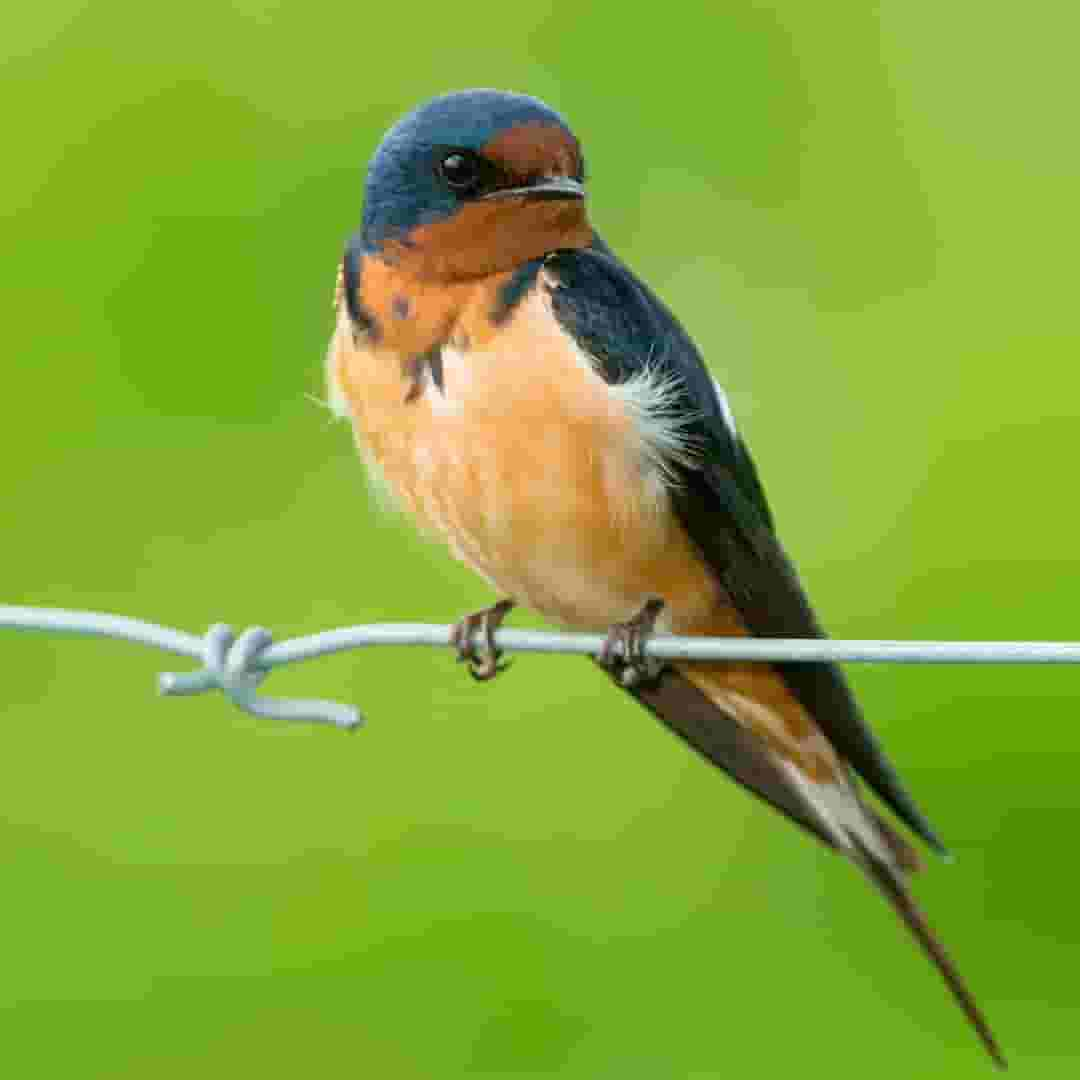

[Bert]: They are the most widespread swallow in the world, but in America, they love building mud nests right on human porches.


[Bert]: here's your input back lil bro-



["your input back lil bro-"]: Hey hows it goin


In [ ]:
# Play Demo
test_file = '/content/drive/MyDrive/HuBERT/test_audio/the-sound-of-swallows.mp3'
bert_demo(test_file)